In [5]:
m_p= 1.67e-27      
k_B= 1.38e-23          
e_charge= 1.602176634e-19  
V_m3= 2955.0 * 1e-6          
data= np.loadtxt(ex1_H+.dat, comments="%")
vx= data[:, 0]
vy= data[:, 1]
vz= data[:, 2]
velocities= data[:,:3]
N= velocities.shape[0]
n_m3 = N / V_m3       
n_cm3 = N / V_cm3    
U= np.mean(velocities,axis=0)
Ux,Uy,Uz= U
thermal_velocities= velocities - U
thermal_speed_squared= np.sum(thermal_velocities**2,axis=1)
mean_thermal_speed_squared= np.mean(thermal_speed_squared)
T_K= m_p* mean_thermal_speed_squared / (3.0*k_B)
T_eV= k_B * T_K/ e_charge

# Equivalent formula:
# T_eV = m_p * mean_thermal_speed_squared / (3.0 * e_charge)

# -----------------------------
# Print results
# -----------------------------
print("no. of ions N =", N)
print()

print("number density:")
print(f"n={n_cm3:.6e} cm^-3")
print()

print("bulk velocity vector:")
print(f"Ux={Ux:.6e} m/s")
print(f"Uy={Uy:.6e} m/s")
print(f"Uz={Uz:.6e} m/s")
print(f"U =[{Ux:.6e}, {Uy:.6e}, {Uz:.6e}] m/s")
print()

print("Temperature:")
print(f"T={T_K:.6e} K")
print(f"T={T_eV:.6e} eV")

no. of ions N = 8866

number density:
n=3.000338e+00 cm^-3

bulk velocity vector:
Ux=-3.918680e+05 m/s
Uy=5.110013e+03 m/s
Uz=1.533652e+04 m/s
U =[-3.918680e+05, 5.110013e+03, 1.533652e+04] m/s

Temperature:
T=1.250333e+05 K
T=1.077454e+01 eV


In [8]:
m_e=9.10e-31        
q_e=1.60e-19        
mu_0=4.0*np.pi* 1e-7     
eps_0=8.85e-12      
gamma=5.0 / 3.0             
B_nT= 7.8                    
B =B_nT * 1e-9               

if data.ndim == 1:
    data = data.reshape(1, -1)

N= vel.shape[0]
rho_m= m_p * n               
U_vec= np.mean(vel, axis=0)  
Ux,Uy,Uz= U_vec
U_mag= np.linalg.norm(U_vec)
thermal_vel= vel - U_vec
thermal_speed_squared= np.sum(thermal_vel**2,axis=1)
mean_thermal_speed_squared= np.mean(thermal_speed_squared)
T_K= m_p * mean_thermal_speed_squared / (3.0 * k_B)
T_eV= k_B * T_K / q_e


c_s= np.sqrt(gamma * k_B * T_K / m_p)
M_s= U_mag / c_s


v_A= B / np.sqrt(mu_0 * rho_m)
M_A= U_mag / v_A


p_kT= n * k_B * T_K
p_B= B**2 / (2.0 * mu_0)
beta= p_kT / p_B


def fast_slow_mhd_speed(c_s, v_A, theta_deg):
    theta= np.deg2rad(theta_deg)
    cos_theta= np.cos(theta)
    term= (c_s**2 + v_A**2)**2 -4.0 * c_s**2 *v_A**2 * cos_theta**2
    term= max(term, 0.0)
    v_fast_squared= 0.5 * ((c_s**2 + v_A**2)+ np.sqrt(term))
    v_slow_squared= 0.5 * ((c_s**2 + v_A**2) - np.sqrt(term))
    v_fast= np.sqrt(max(v_fast_squared, 0.0))
    v_slow= np.sqrt(max(v_slow_squared,0.0))
    return v_fast,v_slow
v_fast_parallel, v_slow_parallel= fast_slow_mhd_speed(c_s, v_A,0.0)
v_fast_perp,v_slow_perp= fast_slow_mhd_speed(c_s, v_A, 90.0)



p_dyn= rho_m * U_mag**2
p_thermal= p_kT
p_magnetic= p_B


omega_ci= q_e * B / m_p
T_ci= 2.0* np.pi / omega_ci


r_g_Hplus= m_p * U_mag / (q_e* B)


n_e= n
omega_pe= np.sqrt(n_e *q_e**2 / (eps_0* m_e))
f_pe= omega_pe /(2.0 * np.pi)


T_e_K = T_K
lambda_D= np.sqrt(eps_0 *k_B*T_e_K/ (n_e * q_e**2))


N_D= (4.0/3.0) *np.pi* n_e *lambda_D**3

# ============================================================
# Print results with substitutions
# ============================================================


print(f"N= {N:d}")
print(f"V= {V_cm3:.6e} cm^3 = {V_m3:.6e} m^3")

print("\n1. Number density")
print(f"n= {N:d} / {V_m3:.6e}")
print(f"n= {n:.6e} m^-3")
print(f"n= {n_cm3:.6e} cm^-3")

print("\n2. Bulk velocity")
print(f"Ux= {Ux:.6e} m/s")
print(f"Uy= {Uy:.6e} m/s")
print(f"Uz= {Uz:.6e} m/s")
print(f"|U|= {U_mag:.6e} m/s")

print("\n3. Temperature")
print(f"T= {T_K:.6e} K")
print(f"T= {T_eV:.6e} eV")

print("\nMass density")
print(f"rho_m= ({m_p:.6e}) * ({n:.6e})")
print(f"rho_m= {rho_m:.6e} kg/m^3")


print("i. Sound speed and sonic Mach number")
print(f"c_s= sqrt(({gamma:.6e})({k_B:.6e})({T_K:.6e}) / ({m_p:.6e}))")
print(f"c_s= {c_s:.6e} m/s")
print("M_s= |U| / c_s")
print(f"M_s= {U_mag:.6e} / {c_s:.6e}")
print(f"M_s= {M_s:.6e}")

print("\nii. Alfven speed and Alfven Mach number")
print(f"v_A= ({B:.6e}) / sqrt(({mu_0:.6e})({rho_m:.6e}))")
print(f"v_A= {v_A:.6e} m/s")
print("M_A= |U| / v_A")
print(f"M_A= {U_mag:.6e} / {v_A:.6e}")
print(f"M_A= {M_A:.6e}")

print("\niii. Plasma beta")
print(f"p_kT= ({n:.6e})({k_B:.6e})({T_K:.6e}) = {p_kT:.6e} Pa")
print(f"p_B= ({B:.6e})^2 / (2({mu_0:.6e})) = {p_B:.6e} Pa")
print(f"beta= {p_kT:.6e} / {p_B:.6e}")
print(f"beta= {beta:.6e}")

print("\niv. Fast and slow MHD wave speeds")

print("\nAlong magnetic field, theta = 0 deg")
print(f"v_fast_parallel= {v_fast_parallel:.6e} m/s")
print(f"v_slow_parallel= {v_slow_parallel:.6e} m/s")

print("\nPerpendicular to magnetic field, theta = 90 deg")
print(f"v_fast_perpendicular= {v_fast_perp:.6e} m/s")
print(f"v_slow_perpendicular= {v_slow_perp:.6e} m/s")

print("\nv. Pressures")
print(f"p_dyn= ({rho_m:.6e})({U_mag:.6e})^2")
print(f"p_dyn= {p_dyn:.6e} Pa")

print(f"p_thermal= ({n:.6e})({k_B:.6e})({T_K:.6e})")
print(f"p_thermal= {p_thermal:.6e} Pa")

print(f"p_magnetic= ({B:.6e})^2 / (2({mu_0:.6e}))")
print(f"p_magnetic= {p_magnetic:.6e} Pa")

print(f"omega_ci= ({q_e:.6e})({B:.6e}) / ({m_p:.6e})")
print(f"omega_ci= {omega_ci:.6e} rad/s")

print(f"T_ci= 2 pi / {omega_ci:.6e}")
print(f"T_ci= {T_ci:.6e} s")

print("\nvii. Pickup ion gyroradius")
print(f"r_g= ({m_p:.6e})({U_mag:.6e}) / (({q_e:.6e})({B:.6e}))")
print(f"r_g= {r_g_Hplus:.6e} m")
print(f"r_g= {r_g_Hplus / 1000.0:.6e} km")

print("\nviii. Electron plasma frequency")
print(f"f_pe= (1 / 2pi) sqrt(({n_e:.6e})({q_e:.6e})^2 / (({eps_0:.6e})({m_e:.6e})))")
print(f"f_pe= {f_pe:.6e} Hz")

print("\nix. Debye length")
print(f"lambda_D= sqrt(({eps_0:.6e})({k_B:.6e})({T_e_K:.6e}) / (({n_e:.6e})({q_e:.6e})^2))")
print(f"lambda_D= {lambda_D:.6e} m")
print(f"lambda_D= {lambda_D * 100.0:.6e} cm")

print("\nx. Number of electrons in Debye sphere")
print(f"N_D= (4/3) pi ({n_e:.6e})({lambda_D:.6e})^3")
print(f"N_D= {N_D:.6e}")

if N_D > 10.0:
    print("Since N_D is much larger than 1, this satisfies an important plasma condition.")
elif N_D > 1:
    print("Since N_D > 1, there are multiple electrons in the Debye sphere.")
else:
    print("Since N_D <= 1, the Debye sphere does not contain many electrons.")

N= 8866
V= 2.955000e+03 cm^3 = 2.955000e-03 m^3

1. Number density
n= 8866 / 2.955000e-03
n= 3.000338e+06 m^-3
n= 3.000338e+00 cm^-3

2. Bulk velocity
Ux= -3.918680e+05 m/s
Uy= 5.110013e+03 m/s
Uz= 1.533652e+04 m/s
|U|= 3.922013e+05 m/s

3. Temperature
T= 1.250333e+05 K
T= 1.077454e+01 eV

Mass density
rho_m= (1.672622e-27) * (3.000338e+06)
rho_m= 5.018432e-21 kg/m^3
i. Sound speed and sonic Mach number
c_s= sqrt((1.666667e+00)(1.380649e-23)(1.250333e+05) / (1.672622e-27))
c_s= 4.147439e+04 m/s
M_s= |U| / c_s
M_s= 3.922013e+05 / 4.147439e+04
M_s= 9.456470e+00

ii. Alfven speed and Alfven Mach number
v_A= (7.800000e-09) / sqrt((1.256637e-06)(5.018432e-21))
v_A= 9.822130e+04 m/s
M_A= |U| / v_A
M_A= 3.922013e+05 / 9.822130e+04
M_A= 3.993037e+00

iii. Plasma beta
p_kT= (3.000338e+06)(1.380649e-23)(1.250333e+05) = 5.179398e-12 Pa
p_B= (7.800000e-09)^2 / (2(1.256637e-06)) = 2.420747e-11 Pa
beta= 5.179398e-12 / 2.420747e-11
beta= 2.139587e-01

iv. Fast and slow MHD wave speeds

Along magnetic

Bulk velocity:
Ux= -3.918680e+05 m/s
Uy= 5.110013e+03 m/s
Uz= 1.533652e+04 m/s


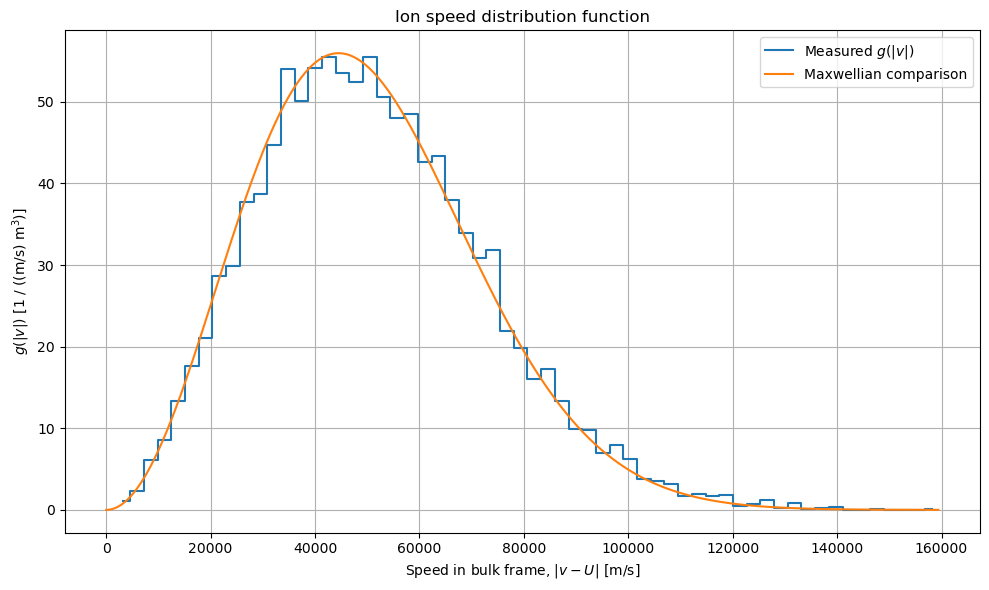

In [12]:
m_p= 1.67e-27     
k_B= 1.38e-23          
n= 3.0e6             
T= 1.20e5                           
V_m3= 2955.0*1e-6         
data= np.loadtxt(ex1_H+.dat,comments="%")
vel= data[:,0:3]
N= vel.shape[0]
U = np.mean(vel,axis=0)
Ux, Uy,Uz= U
print("Bulk velocity:")
print(f"Ux= {Ux:.6e} m/s")
print(f"Uy= {Uy:.6e} m/s")
print(f"Uz= {Uz:.6e} m/s")
w_vec= vel - U
w= np.linalg.norm(w_vec,axis=1)
counts,bin_edges= np.histogram(w, bins=60)
bin_widths= np.diff(bin_edges)
bin_centers= 0.5 *(bin_edges[:-1] + bin_edges[1:])
g_measured= counts / (V_m3 * bin_widths)
dens= np.sum(g_measured*bin_widths)
w_grid = np.linspace(0, np.max(w), 1000)
g_maxwellian = (n*4.0*np.pi * w_grid**2 * (m_p / (2.0*np.pi*k_B* T))**1.5 * np.exp(-m_p* w_grid**2 / (2.0*k_B*T)))

plt.figure(figsize=(10, 6))
plt.plot(bin_centers,g_measured,drawstyle="steps-mid",label="Measured $g(|v|)$")
plt.plot(w_grid,g_maxwellian,label="Maxwellian comparison")
plt.xlabel("Speed in bulk frame, $|v-U|$ [m/s]")
plt.ylabel(r"$g(|v|)$ [1 / ((m/s) m$^3$)]")
plt.title("Ion speed distribution function")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Solar wind bulk velocity from H+ ions:
Ux = -3.918680e+05 m/s
Uy = 5.110013e+03 m/s
Uz = 1.533652e+04 m/s
|U| = 3.922013e+05 m/s


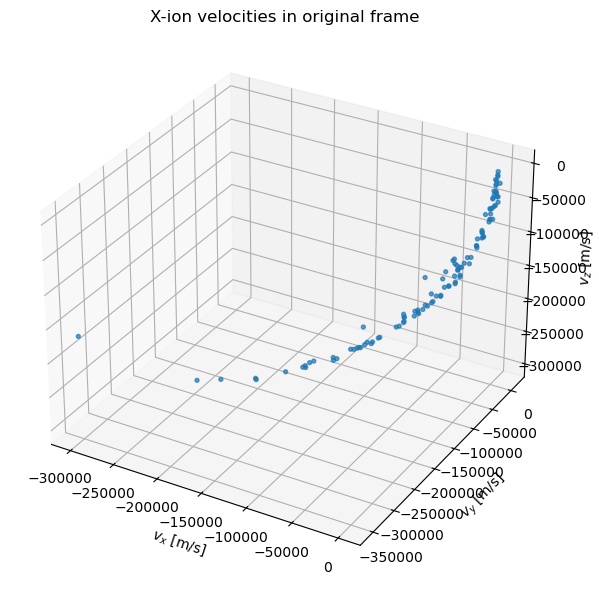

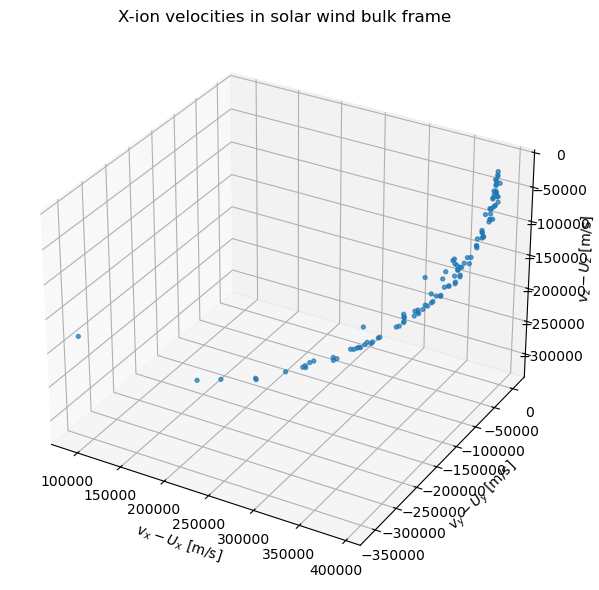


Estimated velocity-space arc plane:
Plane centroid = [ 332718.17483924  -41844.9472889  -174062.31037514] m/s

Estimated magnetic-field direction from arc-plane normal:
B direction unit vector = [-0.80623763  0.54769054  0.22364246]

Note: the sign is ambiguous, so +B_direction and -B_direction are both possible.


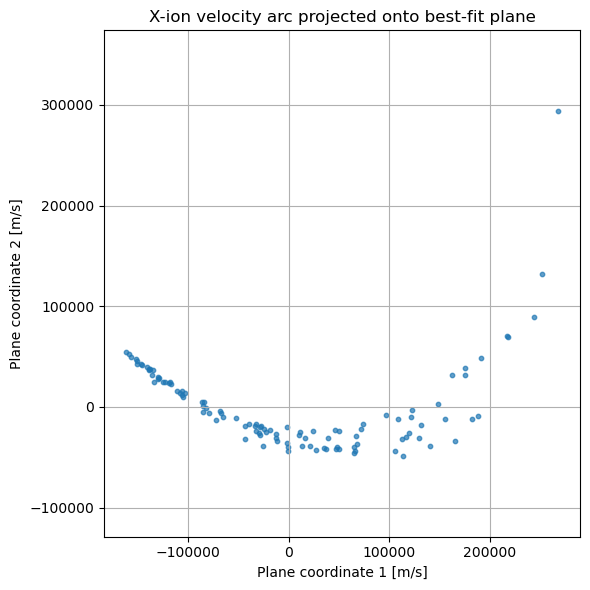


X-ion speed statistics in solar wind frame:
Mean speed = 3.965861e+05 m/s
Median speed = 3.965489e+05 m/s
Max speed = 4.117063e+05 m/s

Rough velocity-space arc radius:
v_perp estimate = 9.684766e+04 m/s


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Constants
# ============================================================

m_p = 1.67262192369e-27      # proton mass [kg]
q_e = 1.602176634e-19        # elementary charge [C]

m_X= 16.0 * m_p
q_X= q_e
H_data= np.loadtxt(ex1_H+.dat, comments="%")
X_data=  np.loadtxt(ex1_ion_X.dat, comments="%")
H_vel= H_data[:, 0:3]
X_vel= X_data[:,0:3]
U_sw= np.mean(H_vel,axis=0)
Ux,Uy,Uz= U_sw
X_vel_sw_frame= X_vel- U_sw

print("Solar wind bulk velocity from H+ ions:")
print(f"Ux = {Ux:.6e} m/s")
print(f"Uy = {Uy:.6e} m/s")
print(f"Uz = {Uz:.6e} m/s")
print(f"|U| = {np.linalg.norm(U_sw):.6e} m/s")

# ============================================================
# Transform X ions into solar wind bulk frame
# ============================================================



# ============================================================
# 3D plot: raw X-ion velocity space
# ============================================================

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_vel[:, 0],
    X_vel[:, 1],
    X_vel[:, 2],
    s=8,
    alpha=0.7
)

ax.set_xlabel(r"$v_x$ [m/s]")
ax.set_ylabel(r"$v_y$ [m/s]")
ax.set_zlabel(r"$v_z$ [m/s]")
ax.set_title("X-ion velocities in original frame")

plt.tight_layout()
plt.show()

# ============================================================
# 3D plot: X-ion velocity space in solar wind frame
# ============================================================

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_vel_sw_frame[:, 0],
    X_vel_sw_frame[:, 1],
    X_vel_sw_frame[:, 2],
    s=8,
    alpha=0.7
)

ax.set_xlabel(r"$v_x - U_x$ [m/s]")
ax.set_ylabel(r"$v_y - U_y$ [m/s]")
ax.set_zlabel(r"$v_z - U_z$ [m/s]")
ax.set_title("X-ion velocities in solar wind bulk frame")

plt.tight_layout()
plt.show()

# ============================================================
# Estimate arc/ring plane using PCA
# The normal vector to this plane is an estimate of B direction.
# ============================================================

points = X_vel_sw_frame

centroid = np.mean(points, axis=0)
points_centered = points - centroid

# Singular value decomposition
U, S, Vt = np.linalg.svd(points_centered, full_matrices=False)

# First two vectors span the arc/ring plane
e1 = Vt[0]
e2 = Vt[1]

# Third vector is normal to the plane
B_direction = Vt[2]
B_direction = B_direction / np.linalg.norm(B_direction)

print()
print("Estimated velocity-space arc plane:")
print(f"Plane centroid = {centroid} m/s")
print()
print("Estimated magnetic-field direction from arc-plane normal:")
print(f"B direction unit vector = {B_direction}")
print()
print("Note: the sign is ambiguous, so +B_direction and -B_direction are both possible.")

# ============================================================
# Project points onto the best-fit plane
# ============================================================

x_plane = points_centered @ e1
y_plane = points_centered @ e2

plt.figure(figsize=(6, 6))
plt.scatter(x_plane, y_plane, s=10, alpha=0.7)
plt.xlabel("Plane coordinate 1 [m/s]")
plt.ylabel("Plane coordinate 2 [m/s]")
plt.title("X-ion velocity arc projected onto best-fit plane")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Optional: estimate arc speed scale
# ============================================================

speed_X_sw_frame = np.linalg.norm(X_vel_sw_frame, axis=1)

print()
print("X-ion speed statistics in solar wind frame:")
print(f"Mean speed = {np.mean(speed_X_sw_frame):.6e} m/s")
print(f"Median speed = {np.median(speed_X_sw_frame):.6e} m/s")
print(f"Max speed = {np.max(speed_X_sw_frame):.6e} m/s")

# A rough perpendicular speed estimate can be obtained from the
# radius of the projected arc in the plane.
arc_radius_velocity = np.median(
    np.sqrt((x_plane - np.mean(x_plane))**2 + (y_plane - np.mean(y_plane))**2)
)

print()
print("Rough velocity-space arc radius:")
print(f"v_perp estimate = {arc_radius_velocity:.6e} m/s")

# ============================================================
# Optional magnetic-field estimate
# ============================================================
# This requires a spatial Larmor radius estimate.
# You must provide r_L from geometry/source distance.
# For example, if you estimate r_L = 500 km, write:
#
# r_L = 500e3
# B_est = m_X * arc_radius_velocity / (q_X * r_L)
# print(f"B estimate = {B_est:.6e} T = {B_est * 1e9:.6e} nT")
# ============================================================